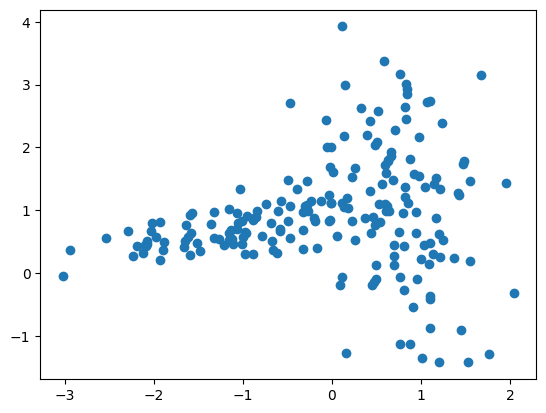

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import random
from sklearn.datasets import make_classification
Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

In [66]:
def initialize_centroids(X, K):
    indices = np.random.choice(X.shape[0], size = K, replace = False)
    return X[indices]

In [67]:
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis = 2)
    return np.argmin(distances, axis = 1)

In [68]:
def update_centroids(X, labels, K):
    new_centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            new_centroids[k] = np.mean(cluster_points, axis = 0)
        else:
            new_centroids[k] = X[np.random.choice(X.shape[0])]
    return new_centroids

In [69]:
def compute_cost(X, centroids, labels):
    cost = 0
    m = X.shape[0]
    for k in range(len(centroids)):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            sq_distances = np.linalg.norm(cluster_points - centroids[k], axis = 1)**2
            cost += np.sum(sq_distances)
    
    return cost / m

In [70]:
def kmeans_single_run(X, K, max_iters = 100, tol = 1e-5):
    centroids = initialize_centroids(X, K)
    prev_cost = float('inf')

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        centroids = update_centroids(X, labels, K)
        cost = compute_cost(X, centroids, labels)

        if abs(prev_cost - cost) < tol:
            break
        prev_cost = cost

    return centroids, labels, cost

In [71]:
def kmeans_best_of(X, K, n_init = 100):
    best_centroids = None
    best_labels = None
    best_cost = float('inf')

    for _ in range(n_init):
        centroids, labels, cost = kmeans_single_run(X, K)

        if cost < best_cost:
            best_cost = cost
            best_centroids = centroids
            best_labels = labels

    return best_centroids, best_labels, best_cost

Final Cost (J): 0.4577


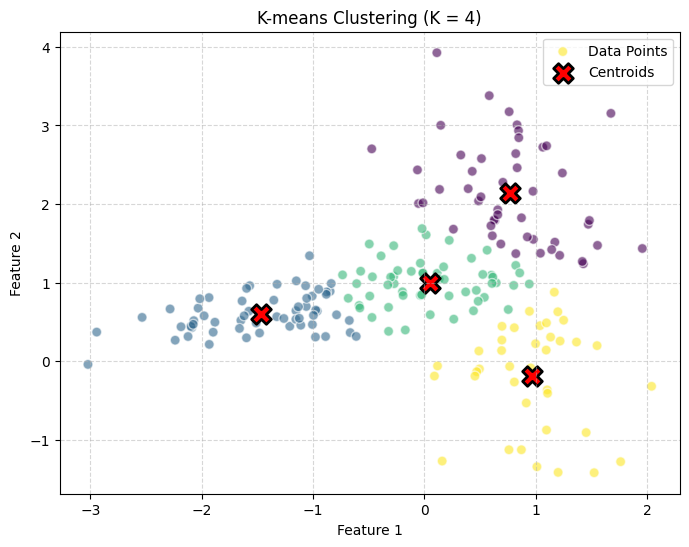

In [72]:
if __name__ == '__main__':
    K = 4
    best_centroids, best_labels, best_cost = kmeans_best_of(Xc_2, K, n_init = 100)
    print (f'Final Cost (J): {best_cost:.4f}')
    plt.figure(figsize = (8, 6))
    plt.scatter(Xc_2[:, 0], Xc_2[:, 1], c = best_labels, marker = 'o', alpha = 0.6, edgecolors = 'w', s = 50, label = 'Data Points')
    plt.scatter(best_centroids[:, 0 ], best_centroids[:, 1], c = 'red', marker = 'X', s = 200, edgecolors = 'black', linewidths = 2, label = 'Centroids')
    plt.title(f'K-means Clustering (K = {K})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, linestyle = '--', alpha = 0.5)
    plt.show()